<a href="https://colab.research.google.com/github/arif124713/all-about-pytorch/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
print(torch.__version__)

2.10.0+cu128


In [ ]:
if torch.cuda.is_available():
  print(f"using gpu: {torch.cuda.get_device_name(0)}")

using gpu: Tesla T4


In [ ]:
torch.empty(5,3,2)

tensor([[[4.1915e-07, 0.0000e+00],
         [3.7952e-04, 0.0000e+00],
         [1.6859e+25, 6.7404e+22]],

        [[6.7120e+22, 4.1576e+21],
         [1.7591e+22, 7.7764e+31],
         [2.7604e+20, 1.7747e+28]],

        [[6.9768e+22, 6.4529e-04],
         [1.3593e-43, 0.0000e+00],
         [4.1670e-08, 0.0000e+00]],

        [[3.7940e-04, 0.0000e+00],
         [1.8098e+31, 9.3312e-40],
         [9.1084e-44, 0.0000e+00]],

        [[2.9202e-12, 4.5071e-41],
         [2.9202e-12, 4.5071e-41],
         [1.6405e-38, 0.0000e+00]]])

In [ ]:
torch.zeros(3,3,5)

tensor([[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]])

In [ ]:
a= torch.rand(3,256,256)

In [ ]:
import matplotlib.pyplot as plt

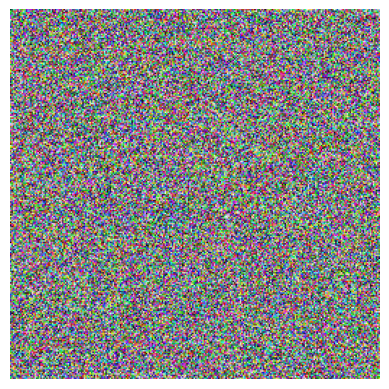

In [ ]:
img = a.permute(1, 2,0)

# Plot with matplotlib
plt.imshow(img)
plt.axis("off")  # Hide axes
plt.show()


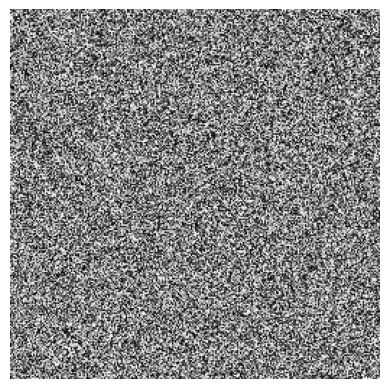

In [ ]:
import torch
import matplotlib.pyplot as plt

# Create random grayscale image (1 channel, 256x256)
a = torch.rand(1, 256, 256)

# Rearrange dimensions to HWC format (256, 256, 1)
img = a.permute(1, 2, 0)

# Plot with matplotlib using a grayscale colormap
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import torch
import numpy as np
from moviepy.editor import ImageSequenceClip

# Example tensor: (frames, channels, height, width)
frames = torch.rand(24, 3, 256, 256)

# Convert frames to numpy arrays in 0–255 range
frame_list = []
for f in frames:
    img = (f.permute(1, 2, 0).numpy() * 255).astype(np.uint8)  # scale + cast
    frame_list.append(img)

# Create video clip (fps = frames per second)
clip = ImageSequenceClip(frame_list, fps=12)

# Write to file
clip.write_videofile("random_video.mp4", codec="libx264")

Moviepy - Building video random_video.mp4.
Moviepy - Writing video random_video.mp4



Moviepy - Done !
Moviepy - video ready random_video.mp4


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.drop(columns=['id', 'Unnamed: 32'], inplace= True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [ ]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

In [ ]:
class MySimpleNN():
  def __init__(self,X):
    self.weights= torch.rand(X.shape[1],1,dtype=torch.float64, requires_grad=True)
    self.bias= torch.zeros(1,dtype=torch.float64, requires_grad=True)

  def forward(self, X):
    z=torch.matmul(X, self.weights)+self.bias
    y_pred= torch.sigmoid(z)
    return y_pred

  def loss_function(self, y_pred,y):
    epsilon = 1e-7
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
    # Calculate loss
    loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1 - y_pred)).mean()
    return loss





In [ ]:
learning_rate=0.1
epochs=250

In [ ]:
model= MySimpleNN(X_train_tensor)

In [ ]:
for epoch in range(epochs):
  #forward pass
  y_pred= model.forward(X_train_tensor)
  #loss_calculation
  loss= model.loss_function(y_pred, y_train_tensor)
  loss.backward()
  with torch.no_grad():
    model.weights-= learning_rate*model.weights.grad
    model.bias-=learning_rate*model.bias.grad

  model.weights.grad.zero_()
  model.bias.grad.zero_()

  #print_loss_in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')



Epoch: 1, Loss: 3.210901065411871
Epoch: 2, Loss: 3.0680631675974714
Epoch: 3, Loss: 2.922244460239057
Epoch: 4, Loss: 2.7719926803892005
Epoch: 5, Loss: 2.6171085511992174
Epoch: 6, Loss: 2.46053127103242
Epoch: 7, Loss: 2.3022313512347643
Epoch: 8, Loss: 2.1447442821345266
Epoch: 9, Loss: 1.9818909254277028
Epoch: 10, Loss: 1.8248899227713804
Epoch: 11, Loss: 1.6754734197910703
Epoch: 12, Loss: 1.5348546574814128
Epoch: 13, Loss: 1.4068373596127073
Epoch: 14, Loss: 1.2928352228166067
Epoch: 15, Loss: 1.193942522897089
Epoch: 16, Loss: 1.1106053286679307
Epoch: 17, Loss: 1.04231510843183
Epoch: 18, Loss: 0.9875467056402347
Epoch: 19, Loss: 0.9440831506394067
Epoch: 20, Loss: 0.9095426158597744
Epoch: 21, Loss: 0.8818057902456915
Epoch: 22, Loss: 0.8591937564534272
Epoch: 23, Loss: 0.8404490302583564
Epoch: 24, Loss: 0.8246471863312848
Epoch: 25, Loss: 0.8111110235775512
Epoch: 26, Loss: 0.7993445641375231
Epoch: 27, Loss: 0.78898464826227
Epoch: 28, Loss: 0.7797650123075696
Epoch: 29,

In [ ]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.6246537566184998


**build a neural network using torch.nn module**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class Model(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.linear= nn.Linear(num_features,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self, features):
    out= self.linear(features)
    out= self.sigmoid(out)
    return out




In [ ]:
features= torch.rand(10,5)
model= Model(features.shape[1])
model(features)

tensor([[0.6817],
        [0.5519],
        [0.5708],
        [0.6383],
        [0.6140],
        [0.5321],
        [0.6191],
        [0.5841],
        [0.5863],
        [0.6327]], grad_fn=<SigmoidBackward0>)

In [ ]:
model.linear.bias

Parameter containing:
tensor([0.1721], requires_grad=True)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
summary(model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [ ]:
class Model(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.linear1= nn.Linear(num_features,3)
    self.relu=nn.ReLU()
    self.linear2= nn.Linear(3,1)
    self.sigmoid= nn.Sigmoid()

  def forward(self, features):
    out= self.linear1(features)
    out= self.relu(out)
    out= self.linear2(out)
    out=self.sigmoid(out)
    return out

In [ ]:
features= torch.rand(10,5)
model= Model(features.shape[1])
model(features)

tensor([[0.4428],
        [0.4434],
        [0.4438],
        [0.4479],
        [0.4433],
        [0.4436],
        [0.4434],
        [0.4441],
        [0.4454],
        [0.4428]], grad_fn=<SigmoidBackward0>)

In [ ]:
model.linear1.weight

Parameter containing:
tensor([[ 0.3877,  0.3119, -0.2537, -0.2671,  0.0846],
        [-0.4058,  0.2327,  0.0884,  0.1081, -0.0119],
        [ 0.0499,  0.4076, -0.3669, -0.1977, -0.1558]], requires_grad=True)

In [ ]:
summary(model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [ ]:
class Model(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.network= nn.Sequential(nn.Linear(num_features,3),
    nn.ReLU(),
   nn.Linear(3,1),
   nn.Sigmoid())

  def forward(self, features):
    out= self.network(features)
    return out



In [ ]:
features= torch.rand(10,5)
model= Model(features.shape[1])
model(features)

tensor([[0.5424],
        [0.5362],
        [0.5406],
        [0.5433],
        [0.5412],
        [0.5433],
        [0.5409],
        [0.5433],
        [0.5253],
        [0.5410]], grad_fn=<SigmoidBackward0>)

**coding on real dataset.. test everything**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
df= pd.read_csv("/content/fashion-mnist_train.csv")

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

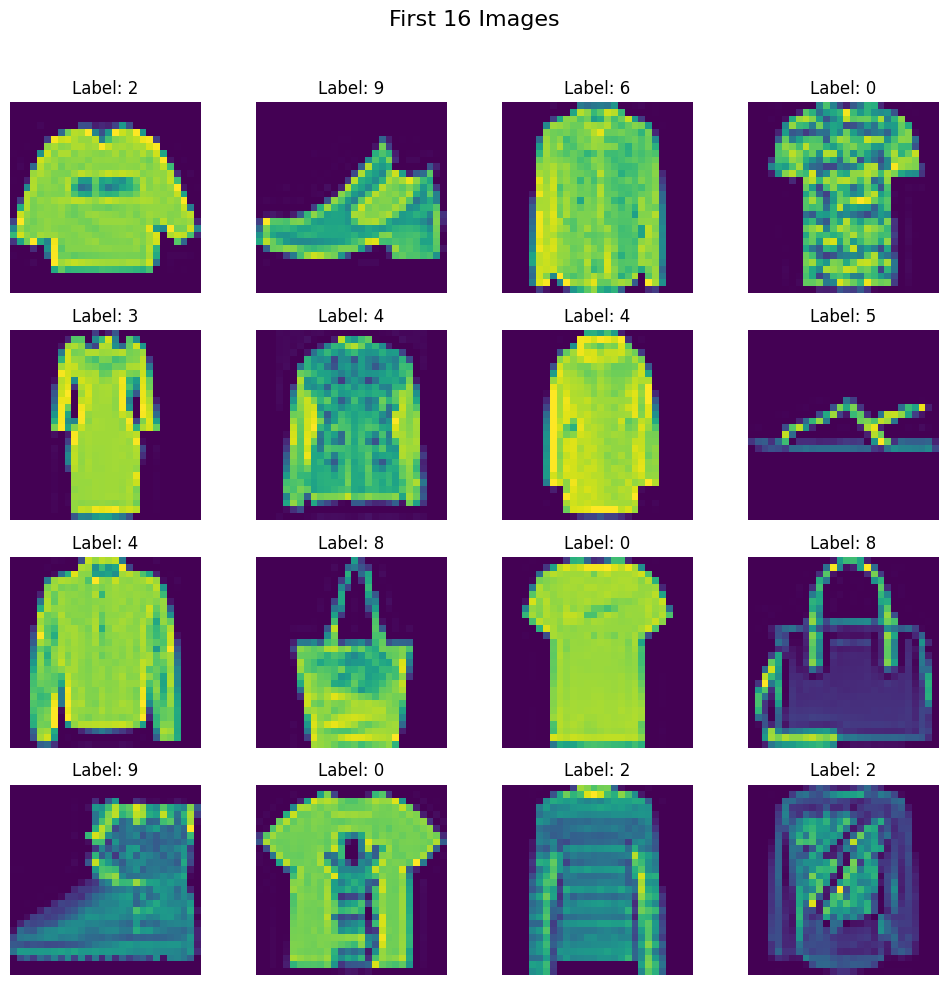

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class customdataset(Dataset):
  def __init__(self, features, labels):
    self.features= torch.tensor(features, dtype=torch.float32)
    self.labels= torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]




In [ ]:
train_dataset= customdataset(X_train,y_train)

In [ ]:
test_dataset = customdataset(X_test, y_test)

In [ ]:
train_loader= DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader= DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [ ]:
##build the nn

class MYnnModule(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model= nn.Sequential(
        nn.Linear(num_features,128),
        nn.BatchNorm1d(128)
        nn.ReLU(),
        nn.Dropout(p=0.3)
        nn.Linear(128,64),
        nn.BatchNorm1d(64)
        nn.ReLU(),
        nn.Dropout(p=0.3)
        nn.Linear(64,28),
        nn.BatchNorm1d(28)
        nn.ReLU(),
        nn.Dropout(p=0.3)
        nn.Linear(28,10)
    )

  def forward(self, X):
    return self.model(X)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1398767546.py, line 8)

In [ ]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.1

In [ ]:
model= MYnnModule(X_train.shape[1])
model= model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate, weight_decay=1e-4)

In [ ]:
for epoch in range (epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels= batch_features.to(device), batch_labels.to(device)
    outputs= model(batch_features)
    loss= criterion(outputs, batch_labels)
    #backward pass
    optimizer.zero_grad()
    loss.backward()
    #update weights
    optimizer.step()
    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.3884330610483885
Epoch: 2 , Loss: 0.3161936207562685
Epoch: 3 , Loss: 0.2953971669599414
Epoch: 4 , Loss: 0.27823827021320663
Epoch: 5 , Loss: 0.26486039442569015
Epoch: 6 , Loss: 0.2552840247526765
Epoch: 7 , Loss: 0.24821844950815042
Epoch: 8 , Loss: 0.2385381808069845
Epoch: 9 , Loss: 0.23063739433450003
Epoch: 10 , Loss: 0.2233662051645418
Epoch: 11 , Loss: 0.21817101005464792
Epoch: 12 , Loss: 0.2131274259208391
Epoch: 13 , Loss: 0.20899011160433292
Epoch: 14 , Loss: 0.2032571538798511
Epoch: 15 , Loss: 0.19776922994075963
Epoch: 16 , Loss: 0.1940234793437024
Epoch: 17 , Loss: 0.18902939114595452
Epoch: 18 , Loss: 0.18472851215985914
Epoch: 19 , Loss: 0.18311922476813197
Epoch: 20 , Loss: 0.1774357647591581
Epoch: 21 , Loss: 0.17811626445005338
Epoch: 22 , Loss: 0.17174910518402856
Epoch: 23 , Loss: 0.17271858857447903
Epoch: 24 , Loss: 0.16641814569321772
Epoch: 25 , Loss: 0.16211012314197917
Epoch: 26 , Loss: 0.15984565119072794
Epoch: 27 , Loss: 0.15469174464

In [ ]:
# set model to eval mode
model.eval()

MYnnModule(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=28, bias=True)
    (5): ReLU()
    (6): Linear(in_features=28, out_features=10, bias=True)
  )
)

In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels= batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8834166666666666


In [ ]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels= batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.95775


# **Creating CNN in pytorch**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)

Using device: cuda


In [10]:
df = pd.read_csv('/content/fashion-mnist_train.csv', on_bad_lines='skip')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df.shape

(60000, 785)

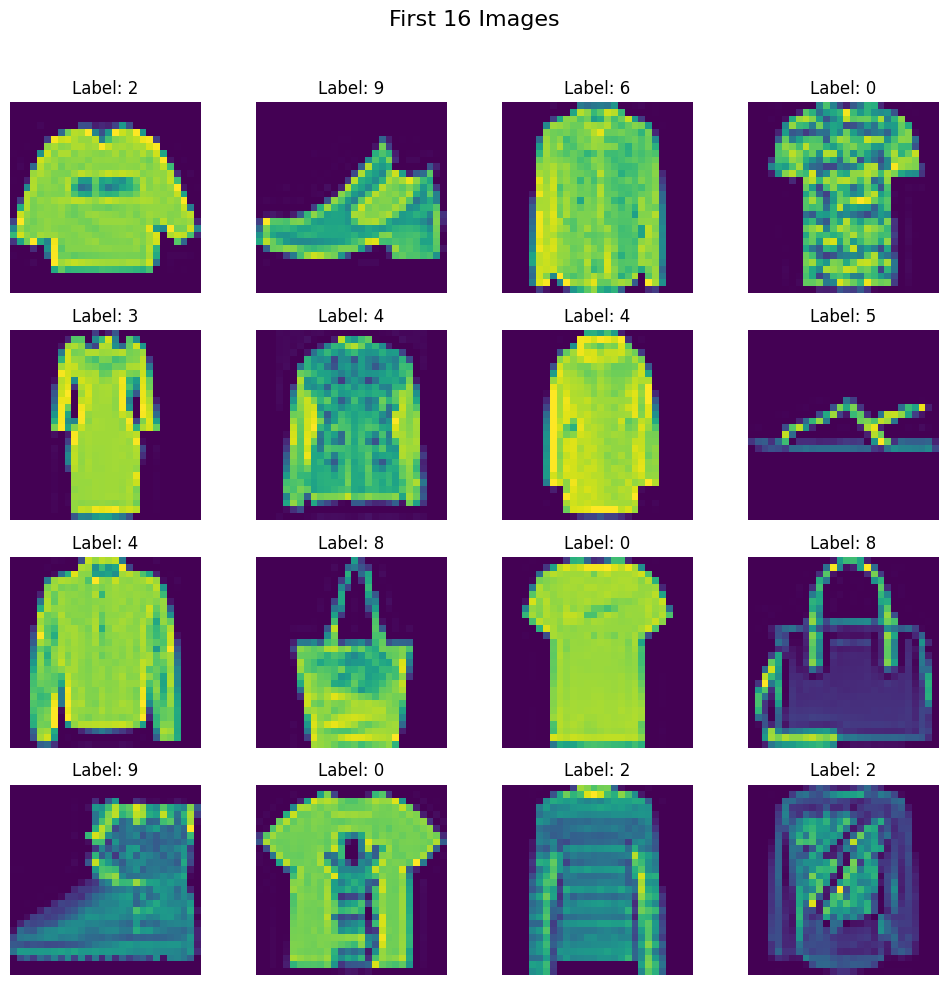

In [12]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [13]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train = X_train/255.0
X_test = X_test/255.0

In [19]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28) ##here the difference
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [20]:
train_dataset = CustomDataset(X_train, y_train)

In [21]:
test_dataset = CustomDataset(X_test, y_test)

In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [23]:
class MyNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [24]:
learning_rate = 0.01
epochs = 100

In [25]:
model = MyNN(1)

torch.cuda.empty_cache()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [26]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6456768243610859
Epoch: 2 , Loss: 0.38638479592402775
Epoch: 3 , Loss: 0.32709261870880924
Epoch: 4 , Loss: 0.29152595955630145
Epoch: 5 , Loss: 0.2660155636991064
Epoch: 6 , Loss: 0.24538497133615117
Epoch: 7 , Loss: 0.23094851393873492
Epoch: 8 , Loss: 0.2124711140965422
Epoch: 9 , Loss: 0.2020241707439224
Epoch: 10 , Loss: 0.18858849592568974
Epoch: 11 , Loss: 0.17457671105799574
Epoch: 12 , Loss: 0.16832097078238925
Epoch: 13 , Loss: 0.15552617188884565
Epoch: 14 , Loss: 0.1465672778300941
Epoch: 15 , Loss: 0.14151685088096808
Epoch: 16 , Loss: 0.13311692351506402
Epoch: 17 , Loss: 0.1256761795668863
Epoch: 18 , Loss: 0.12194183967262506
Epoch: 19 , Loss: 0.11301413199212403
Epoch: 20 , Loss: 0.10912066084643204
Epoch: 21 , Loss: 0.10514531164399038
Epoch: 22 , Loss: 0.09852282153038928
Epoch: 23 , Loss: 0.09264488080112884
Epoch: 24 , Loss: 0.08600576029811055
Epoch: 25 , Loss: 0.08301753594082159
Epoch: 26 , Loss: 0.08473238230488885
Epoch: 27 , Loss: 0.0776523

In [27]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [28]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9265


In [29]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9997916666666666


In [30]:
!pip install optuna

**Hyper parameter tuning using optuna**

In [31]:
import torch.nn.functional as F
import optuna
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# Define your model with tunable hyperparameters
class MyNN(nn.Module):
    def __init__(self, input_features, trial):
        super().__init__()

        # Tune number of filters
        n_filters1 = trial.suggest_int("n_filters1", 16, 64)
        n_filters2 = trial.suggest_int("n_filters2", 32, 128)

        self.features = nn.Sequential(
            nn.Conv2d(input_features, n_filters1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(n_filters1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(n_filters1, n_filters2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(n_filters2),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Tune hidden layer sizes
        hidden1 = trial.suggest_int("hidden1", 64, 256)
        hidden2 = trial.suggest_int("hidden2", 32, 128)

        # Tune dropout
        dropout1 = trial.suggest_float("dropout1", 0.2, 0.6)
        dropout2 = trial.suggest_float("dropout2", 0.2, 0.6)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_filters2 * 7 * 7, hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout1),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout2),

            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Objective function for Optuna
def objective(trial):
    # Data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_dataset = CustomDataset(X_train, y_train)
    test_dataset = CustomDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

    # Model
    model = MyNN(input_features=1, trial=trial)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Optimizer
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr)

    # Training loop
    epochs = 50
    for epoch in range(epochs):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = F.cross_entropy(output, target)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    accuracy = correct / total
    return accuracy


# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2026-03-26 17:16:31,196] A new study created in memory with name: no-name-a8cafd26-6b54-41fd-b283-448f069b9b6b
[I 2026-03-26 17:19:56,833] Trial 0 finished with value: 0.9220833333333334 and parameters: {'n_filters1': 39, 'n_filters2': 111, 'hidden1': 179, 'hidden2': 94, 'dropout1': 0.5124880213239198, 'dropout2': 0.5470596711742406, 'lr': 0.001280392946979679, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.9220833333333334.
[I 2026-03-26 17:23:21,549] Trial 1 finished with value: 0.9228333333333333 and parameters: {'n_filters1': 52, 'n_filters2': 97, 'hidden1': 231, 'hidden2': 67, 'dropout1': 0.4454455653785985, 'dropout2': 0.5730399788260403, 'lr': 0.006052542117926207, 'optimizer': 'SGD'}. Best is trial 1 with value: 0.9228333333333333.
[I 2026-03-26 17:26:49,628] Trial 2 finished with value: 0.92225 and parameters: {'n_filters1': 63, 'n_filters2': 110, 'hidden1': 110, 'hidden2': 50, 'dropout1': 0.3428082780706182, 'dropout2': 0.30390851092447296, 'lr': 0.0031913578367054616,

Best hyperparameters: {'n_filters1': 52, 'n_filters2': 97, 'hidden1': 231, 'hidden2': 67, 'dropout1': 0.4454455653785985, 'dropout2': 0.5730399788260403, 'lr': 0.006052542117926207, 'optimizer': 'SGD'}
Best accuracy: 0.9228333333333333
